# 📝 Instrucciones: Prediciendo la diabetes

Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.

---

## Paso 1: Carga del conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre `diabetes.csv`. Puedes cargarlo en el código directamente desde el siguiente enlace:

[https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv](https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv)

O descargarlo y añadirlo a mano en tu repositorio. En este conjunto de datos encontrarás las siguientes variables:

* **Pregnancies.** Número de embarazos del paciente (numérico)
* **Glucose.** Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)
* **BloodPressure.** Presión arterial diastólica (medida en mm Hg) (numérico)
* **SkinThickness.** Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)
* **Insulin.** Insulina sérica de 2 horas (medida en mu U/ml) (numérico)
* **BMI.** Índice de masa corporal (numérico)
* **DiabetesPedigreeFunction.** Función de pedigrí de diabetes (numérico)
* **Age.** Edad del paciente (numérico)
* **Outcome.** Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)

---

## Paso 2: Realiza un EDA completo
Este segundo paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

Asegúrate de dividir convenientemente el conjunto de datos en **train** y **test** como hemos visto en lecciones anteriores.

---

## Paso 3: Construye un modelo de árbol de decisión
Comienza a resolver el problema implementando un árbol de decisión y analiza cuál de los dos tipos satisface tus necesidades. Entrénalo y analiza sus resultados. Prueba a modificar la función de cálculo de la pureza de los nodos y utiliza todas las disponibles. Descríbelas y analiza sus resultados graficándolos.

---

## Paso 4: Optimiza el modelo anterior
Después de entrenar el árbol con las distintas funciones de pureza, selecciona el mejor de ellos y optimiza sus hiperparámetros utilizando un grid search.

---

## Paso 5: Guarda el modelo
Almacena el modelo en la carpeta correspondiente.

In [19]:
#Importo todas las librerias que voy a necesitar
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import numpy as np
#Importamos joblib para guardar modelos de base de datos
import joblib
from sklearn.metrics import precision_recall_curve, classification_report
#Importamos tree para diujar el desitiontree
from sklearn import tree
# OJO!!!! las funciones create_factor_transf_and_json, prepare_test_data y train_print_model son de creacion personal estan en utils
# (archivo que ya existia en este repositorio).
from utils import  prepare_test_data, train_print_model

In [20]:
# Cargamos el dataset
total_data = pd.read_csv('../data/raw/diabetes.csv')
total_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [21]:
#imprimimos el numero de filas
print(f"Numero De Filas en 'total_data': {len(total_data)}")

# Verificamos La Cantidad De Variables Por Tipos De Datos en total_data que son los datos que vamos a aplicar el EDA:
pd.Series.value_counts(total_data.dtypes)

Numero De Filas en 'total_data': 768


int64      7
float64    2
Name: count, dtype: int64

In [22]:
print("------------------PORCENTAJE DE VALORES NULOS DEL total_data---------------------\n")
#Obtenemos que columnas tienen valores nulos y porcentage respectivamente
info_nulls = pd.DataFrame({
    '% Nullidad': total_data.isna().sum() / len(total_data) * 100
}).sort_values(by='% Nullidad', ascending=False)
info_nulls


------------------PORCENTAJE DE VALORES NULOS DEL total_data---------------------



,% Nullidad
Pregnancies,0.0
Glucose,0.0
BloodPressure,0.0
SkinThickness,0.0
Insulin,0.0
BMI,0.0
DiabetesPedigreeFunction,0.0
Age,0.0
Outcome,0.0


In [23]:
total_data.describe(include = 'all')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Analisis (Hasta Ahora):
* Tenemos un dataframe total_data con 9 columnas y 768  filas
* 7 columnas son int64 y 2 float64, no hay ninguna srt
* Ninguna de esas columnas tienen valores nulos.
* `outcome` es nuestro target, representa si el paciente tiene diabetes o no.
* como todas las variables en principio son numericas no vaos a buscar unicidad buscando factorizar, al menos no por ahora.
* hay muchas columnas con valores en 0, pero esto en una persona es imposible, asi que es un dato faltante.

In [24]:
# Listamos las columnas donde el 0 no tiene sentido
cols_with_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Reemplazamos 0 por nan para luego ejecutar fillna
total_data[cols_with_ceros] = total_data[cols_with_ceros].replace(0, np.nan)

# usamos la mediana de cada columna
total_data.fillna(total_data.median(), inplace = True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


In [25]:
total_data.describe(include = 'all')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [26]:
total_data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

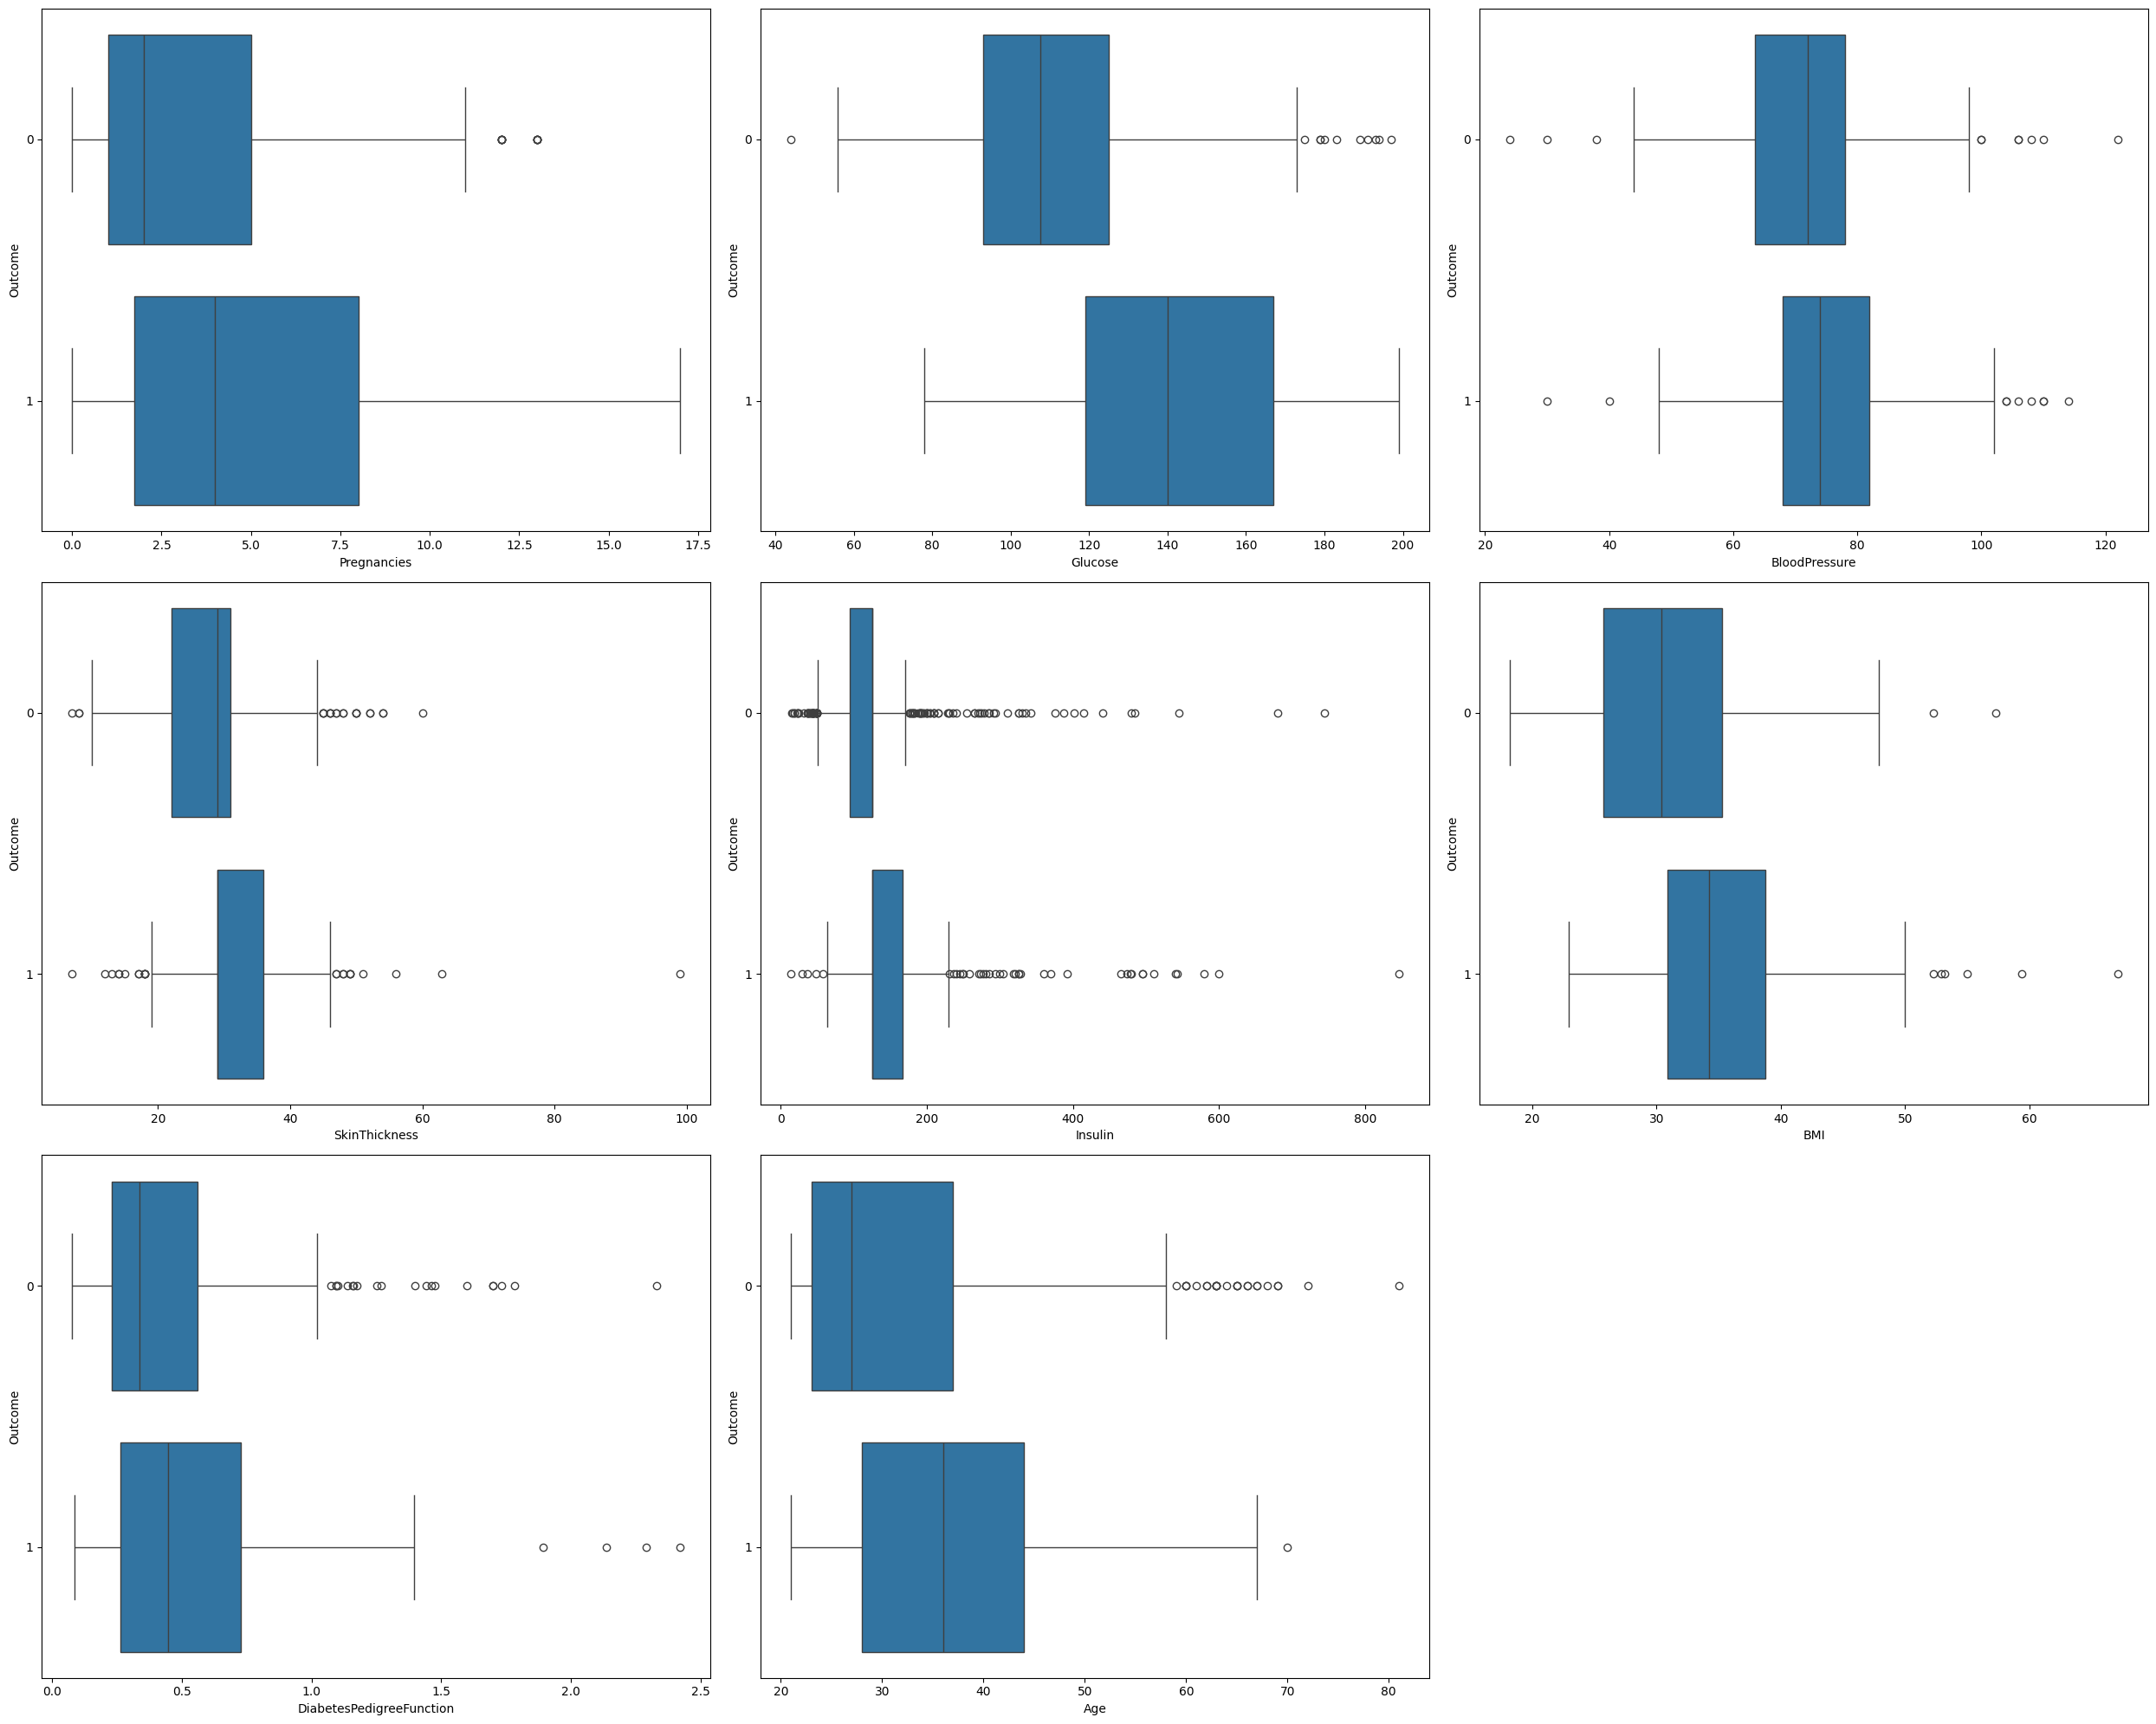

In [27]:
#Vamos a graficar todas las variables en varior boxplot basandonos en nuestro target outcome
fig = plt.figure(figsize=(25, 20))

# Creamos el grid de 3x5
axis = gridspec.GridSpec(3, 3, figure = fig)

axis0 = fig.add_subplot(axis[0, 0]); sns.boxplot(data = total_data, orient = "h", y = 'Outcome', x = 'Pregnancies', ax = axis0)
axis1 = fig.add_subplot(axis[0, 1]); sns.boxplot(data = total_data, orient = "h", y = 'Outcome', x = 'Glucose', ax = axis1)
axis2 = fig.add_subplot(axis[0, 2]); sns.boxplot(data = total_data, orient = "h", y = 'Outcome', x = 'BloodPressure', ax = axis2)
axis4 = fig.add_subplot(axis[1, 0]); sns.boxplot(data = total_data, orient = "h", y = 'Outcome', x = 'SkinThickness', ax = axis4)
axis3 = fig.add_subplot(axis[1, 1]); sns.boxplot(data = total_data, orient = "h", y = 'Outcome', x = 'Insulin', ax = axis3)
axis5 = fig.add_subplot(axis[1, 2]); sns.boxplot(data = total_data, orient = "h", y = 'Outcome', x = 'BMI', ax = axis5)
axis6 = fig.add_subplot(axis[2, 0]); sns.boxplot(data = total_data, orient = "h", y = 'Outcome', x = 'DiabetesPedigreeFunction', ax = axis6)
axis7 = fig.add_subplot(axis[2, 1]); sns.boxplot(data = total_data, orient = "h", y = 'Outcome', x = 'Age', ax = axis7)


# Ajustar Layout para que no se solapen los títulos
plt.tight_layout()
plt.show()

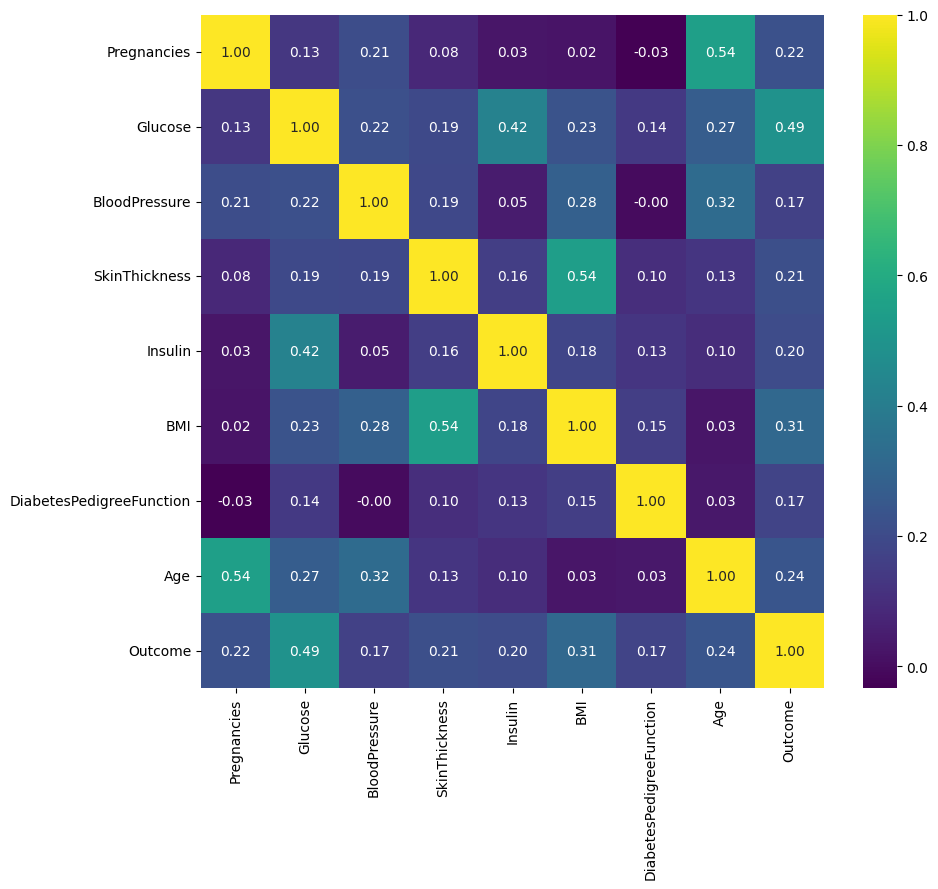

In [28]:
#Diujamos un heatmap para ver correlaciones numericas
cols_num = total_data.select_dtypes(include = ['number']).columns
fig, ax = plt.subplots(figsize = (10,  9))
sns.heatmap(total_data[cols_num].corr(method = "pearson"), annot = True, fmt = ".2f", cmap = "viridis", ax = ax)
plt.tight_layout()
plt.show()

## Interpretacion de los graficos:
| Variable | Descripción | Interpretación |
| :--- | :--- | :--- |
| **Pregnancies** | Número de embarazos del paciente (numérico) | Vemos 2 cajas casi sin outliers donde los casos de embarazos aumentan a media medida la probabilidad de diabetes,su currelacion de 0.22 no es ni la mas baja ni la mas alta pero es relevante |
| **Glucose** | Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico) | Es nuestra variable estrella, el box plot lo muestra la segunda caja como muy superior, ademas tiene una correlacion de 0.49 |
| **BloodPressure** | Presión arterial diastólica (medida en mm Hg) (numérico) | Las dos cajas muestran un similaridad identica en cuanto a tamaño una ligeramente elevada sobre la otra, incluso con ouliers parecidos su correlacion en 0.17, aunque es la mas baja, es la mas consistente, en una regresion lineal seria una ligera pendiente.|
| **SkinThickness** | Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico) | son parecidas las dos cajas aunque no tanto como el punto anterior,los diabeticos tiene un outlier con un valor de 99 que se aleja bastante del ultimo quarter, su correlacion es de 0.21 |
| **Insulin** | Insulina sérica de 2 horas (medida en mu U/ml) (numérico) | Graficos tambien parecidos, con diabeticos ligeramente por arriba del los no diabeticos y con muchos outliers ambos, pero outliers similares, su correlacion es de 0.20 |
| **BMI** | Índice de masa corporal (numérico) | hasta este punto se sigue un patron parecido en que la segunda caja la de los diabeticos supera en menor o mayor medida a la otra caja, en este caso son similares con la diferencia de que hay un outlier en los diabeticos que se aleja bastante. Tambien esta es la degunda variable que mas correlacion tiene 0.31 |
| **DiabetesPedigreeFunction** | Función de pedigrí de diabetes (numérico) | Aca las cajas son un poco diferentes pero siguiendo la misma tonica,  aca los outliers se presentan mas en los no diabeticos aunque no se dispara a niveles altisimos, su correlacion es de 0.17 no muy alta pero sigue siendo util |
| **Age** | Edad del paciente (numérico) | aca se puede observar que hay muchos outliers en pacientes no diabeticos, y en pacientes diabeticos casi sin outliers, quizas nos diga que los que no sufren de diabetes son mas propensos a llegar a altas edades. la correlacion es de 0.24 |


In [29]:
# Realmente todas las variables nos aportan info util asi que no vamos a eliminar ninguna 
# Creamos los datos de entrenamiento
ptd = prepare_test_data(total_data, "Outcome", "Diabetes1Ejercicio4", scaler_type = 0)
ptd.x_train_out.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84.0,72.0,29.0,125.0,32.3,0.304,21
618,9,112.0,82.0,24.0,125.0,28.2,1.282,50
346,1,139.0,46.0,19.0,83.0,28.7,0.654,22
294,0,161.0,50.0,29.0,125.0,21.9,0.254,65
231,6,134.0,80.0,37.0,370.0,46.2,0.238,46


In [30]:
#Le pasamos los datos al modelo con type_model = "dt" de desition tree
tpm = train_print_model(ptd, type_model = "dt")
report_no_out = tpm.report_no_out
report_out = tpm.report_out
print(report_no_out)
print(report_out)

--- REPORTE SIN OUTLIERS (DecisionTreeClassifier) ---
              precision    recall  f1-score   support

           0       0.84      0.73      0.78        99
           1       0.60      0.75      0.67        55

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.75      0.73      0.74       154

--- REPORTE CON OUTLIERS (DecisionTreeClassifier) ---
              precision    recall  f1-score   support

           0       0.83      0.71      0.77        99
           1       0.59      0.75      0.66        55

    accuracy                           0.72       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.74      0.72      0.73       154



# Conclusiones hasta ahora:
por ahora solo tenemos una presicion de 60% con una sensibilidad del 75% no es del todo malo pero vamos a ver si subimos mas esos resultados. 

In [31]:
# Cambiamos el balance de clases porque 1,es decir los diabeticos es mas importante
proportion = {0:1, 1:3}
#Volvemos a entrenar el modelo pero con el balance de clases, una calibracion_cv de 5 y profundidad de arbol de 7
#Tambien probamos con los diferentes criterion "gini", "entropy", "log_loss"
criterions = ["gini", "entropy", "log_loss"]
for crit in criterions:
    # Entrenamos pasandole el criterio
    tpm = train_print_model(ptd, type_model="dt", class_weight = proportion, calibrate_cv = 5, max_depth = 7, criterion = crit)
    preds = tpm.model_no_out.predict(ptd.x_test_no_out)
    report_dict = classification_report(ptd.y_test_no_out, preds, output_dict = True)
    
    # Extraer solo lo que nos interesa,es decir (clase 1 = diabetico)
    precision_1 = report_dict['1']['precision']
    recall_1 = report_dict['1']['recall']

    print(f"Criterio: {crit:10} ||| Precision (clase 1): {precision_1:.4f} ||| Recall (clase 1): {recall_1:.4f}")

Criterio: gini       ||| Precision (clase 1): 0.7045 ||| Recall (clase 1): 0.5636
Criterio: entropy    ||| Precision (clase 1): 0.6279 ||| Recall (clase 1): 0.4909
Criterio: log_loss   ||| Precision (clase 1): 0.6279 ||| Recall (clase 1): 0.4909


In [32]:
#Entonses usamos gini porque nos da la mejor presicion y recall
tpm = train_print_model(ptd, type_model="dt", class_weight=proportion, calibrate_cv = 5, max_depth = 7, criterion = "gini")
report_no_out = tpm.report_no_out
report_out = tpm.report_out
print(report_no_out)
print(report_out)

--- REPORTE SIN OUTLIERS (DecisionTreeClassifier) ---
              precision    recall  f1-score   support

           0       0.78      0.87      0.82        99
           1       0.70      0.56      0.63        55

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.72       154
weighted avg       0.75      0.76      0.75       154

--- REPORTE CON OUTLIERS (DecisionTreeClassifier) ---
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        99
           1       0.74      0.62      0.67        55

    accuracy                           0.79       154
   macro avg       0.77      0.75      0.76       154
weighted avg       0.78      0.79      0.78       154



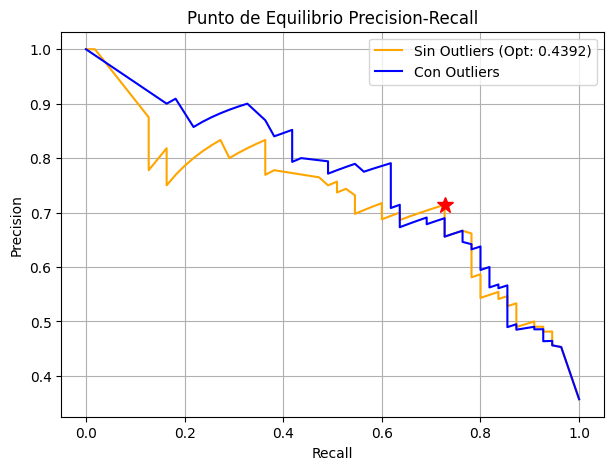

El umbral sugerido es: 0.4392


In [33]:
# Vi en internet que podemos observar mas o menos la relacion entre el recall y el presition tratando de encontrar un "punto de equilibrio"
p, r, t = precision_recall_curve(ptd.y_test_no_out, tpm.probs_no_out)
p2, r2, t2 = precision_recall_curve(ptd.y_test_out, tpm.probs_out)

# Hallar umbral optimo (Distancia minima a 1,1)
dist = np.sqrt((1-r)**2 + (1-p)**2)
idx = np.argmin(dist)
# Nota: thresholds tiene N-1 elementos respecto a precision/recall
opt_t = t[idx] if idx < len(t) else t[-1] 

# Grafico
plt.figure(figsize=(7, 5))
plt.plot(r, p, label=f'Sin Outliers (Opt: {opt_t:.4f})', color = 'orange')
plt.plot(r2, p2, label='Con Outliers', color = 'blue')
plt.plot(r[idx], p[idx], 'r*', markersize=12) # Estrella en el punto

plt.title('Punto de Equilibrio Precision-Recall')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.legend(); plt.grid(True); plt.show()

print(f"El umbral sugerido es: {opt_t:.4f}")

In [34]:
#Modificamos el umbral 
tpm = train_print_model(ptd, type_model = "dt", class_weight=proportion,umbral=0.4392, calibrate_cv = 5, max_depth = 7, criterion = "gini")
report_no_out = tpm.report_no_out
report_out = tpm.report_out
print(report_no_out)
print(report_out)

--- REPORTE SIN OUTLIERS (DecisionTreeClassifier) ---
              precision    recall  f1-score   support

           0       0.85      0.84      0.84        99
           1       0.71      0.73      0.72        55

    accuracy                           0.80       154
   macro avg       0.78      0.78      0.78       154
weighted avg       0.80      0.80      0.80       154

--- REPORTE CON OUTLIERS (DecisionTreeClassifier) ---
              precision    recall  f1-score   support

           0       0.84      0.82      0.83        99
           1       0.68      0.71      0.70        55

    accuracy                           0.78       154
   macro avg       0.76      0.76      0.76       154
weighted avg       0.78      0.78      0.78       154



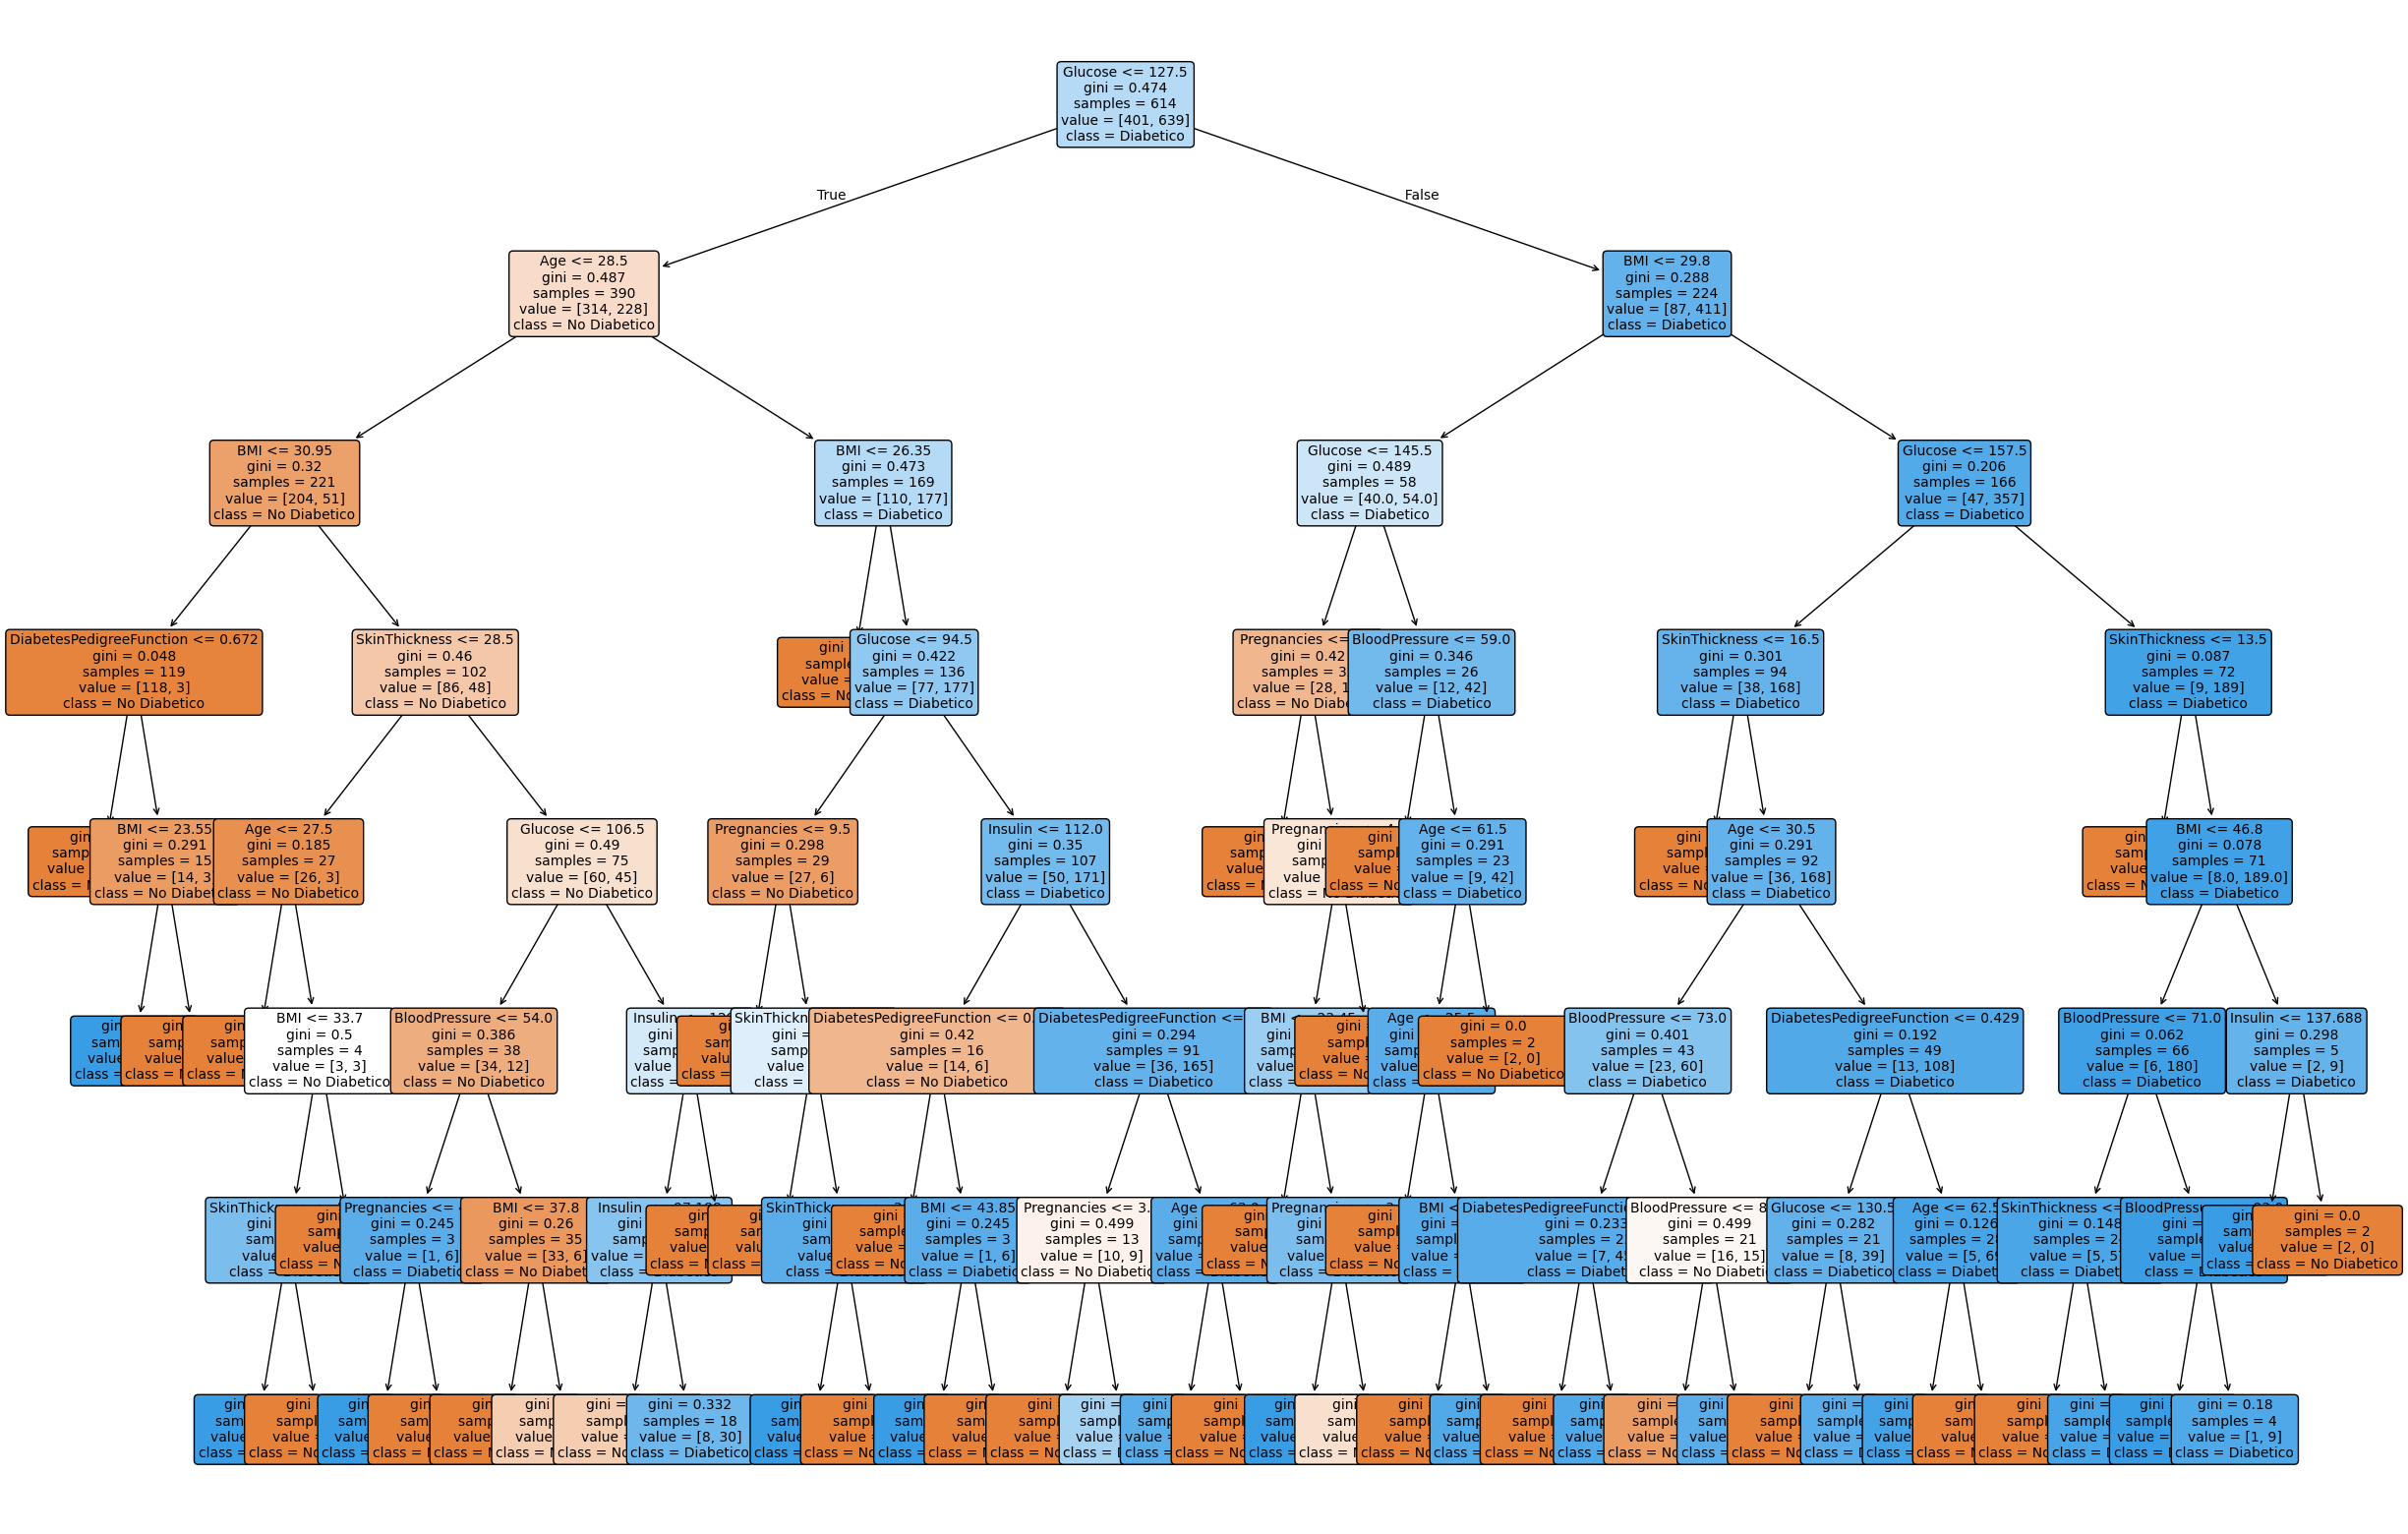

In [35]:
#Para dibujar el modelo no puede estar calibrado con calibrate_cv = 5
tpm2 = train_print_model(ptd, type_model = "dt", class_weight=proportion, umbral=0.4392, max_depth = 7, criterion = "gini")
plt.figure(figsize=(30, 20))
# Graficamos el plot_tree
tree.plot_tree(tpm2.model_no_out, feature_names = ptd.x_train_no_out.columns,  class_names = ['No Diabetico', 'Diabetico'], filled = True, rounded = True, fontsize = 10)
plt.show()

# Conclusiones finales
* El nodo raiz es la glucosa <= 127.5 con un gini de 0.474
* Como habiamos especificado el arbol tiene 7 ramificaciones.
* El criterio "gini" es es que nos da mejores resultados.
* Con la modificacion de parametros logramos aumentar la presicion de los modelos con y sin outliers de 59% y 60% a 68% y 71% respectivammente, sin bajar mucho su recall que es importantisimo en el ambito de la salud.
* Ambos son buenos pero vamos a priorizar el modelo sin outliers, dado que el tema es la salud no podemos sabrificar mucho recall dado que dejariamos a muchos pacientes por fuera y sin prediccion.

In [36]:
# Creamos un paquete para exportarlo todo junto el modelo y los x_train, x_test, y_train, y_test
model_pack = {
    'model': tpm.model_no_out,
    'x_train': ptd.x_train_no_out,
    'x_test': ptd.x_test_no_out,
    'y_train': ptd.y_train_no_out,
    'y_test': ptd.y_test_no_out
}

#  Guardamos el paquete
path = f"../data/processed/models/diabetes04/"
if not os.path.exists(path):
    os.makedirs(path)
#  Guardamos el paquete
joblib.dump(model_pack, f'{path}diabetes_pack.pkl')


['../data/processed/models/diabetes04/diabetes_pack.pkl']